#### validation dataset generation   

In [1]:
import torch
import numpy as np
from glob import glob
import rasterio as rio
from pyrsimg import img2patch
from pyrsimg import imsShow, imgShow
from torchvision.transforms import v2 


In [2]:
dir_val_scene = 'data/dset/val/scene' 
dir_val_truth = 'data/dset/val/truth' 
dir_val_patch = 'data/dset/val_patch' 
patch_size = 512  ## base patch size
# ## valset
paths_val_scene = sorted(glob(dir_val_scene+'/*.tif'))
paths_val_truth = sorted(glob(dir_val_truth+'/*.tif'))
paths_valset = list(zip(paths_val_scene, paths_val_truth))
print(len(paths_valset))   
paths_valset[4]   


43


('data/dset/val/scene/S2A_L2A_20190508_N0212_R078_S3.tif',
 'data/dset/val/truth/S2A_L2A_20190508_N0212_R078_S3_truth.tif')

In [3]:
## generate validation patches (include patch,dem,truth)
dset_patch_list = []
dset_start_list = []
dset_list = []       ## [patches, higher_patches]
for path_scene,  path_truth in paths_valset:
    print(path_scene)
    scene_val_arr = rio.open(path_scene).read()   ## (C, H, W)
    truth_val_arr = rio.open(path_truth).read(1)
    size_global = scene_val_arr.shape[1:]
    ## image to patches
    scene_truth_arr = np.concatenate([scene_val_arr, 
                                        truth_val_arr[np.newaxis, ...]], 
                                        axis=0)
    scene_truth_arr_ = torch.from_numpy(scene_truth_arr).to(dtype=torch.float16)
    img2patches = img2patch(img = scene_truth_arr_.numpy().transpose(1,2,0), 
                            patch_size = patch_size, 
                            edge_overlay = 50)     ## 50 for patch_512, 100 for patch_1024
    patch_truth_list = img2patches.toPatch()  
    patch_lat_list = [scene_val_arr]*len(patch_truth_list)
    print(len(patch_truth_list))
    dset_list.extend(patch_truth_list)
    # break
print('num of patches:', len(dset_list))


data/dset/val/scene/S2A_L2A_20190125_N0211_R034_S1.tif
4
data/dset/val/scene/S2A_L2A_20190206_N0211_R067_S3.tif
9
data/dset/val/scene/S2A_L2A_20190318_N0211_R061_S2.tif
4
data/dset/val/scene/S2A_L2A_20190429_N0211_R096_S1.tif
6
data/dset/val/scene/S2A_L2A_20190508_N0212_R078_S3.tif
4
data/dset/val/scene/S2A_L2A_20190716_N0213_R063_S2.tif
6
data/dset/val/scene/S2A_L2A_20190725_N0213_R054_S1.tif
4
data/dset/val/scene/S2A_L2A_20190811_N0213_R013_S2.tif
9
data/dset/val/scene/S2A_L2A_20190817_N0213_R089_S4.tif
4
data/dset/val/scene/S2B_L2A_20181226_N0211_R102_S2.tif
9
data/dset/val/scene/S2B_L2A_20190303_N0211_R065_S1.tif
9
data/dset/val/scene/S2B_L2A_20190430_N0211_R035_S3.tif
9
data/dset/val/scene/S2B_L2A_20190607_N0212_R012_S2.tif
6
data/dset/val/scene/S2B_L2A_20190620_N0212_R053_S1.tif
9
data/dset/val/scene/S2B_L2A_20190801_N0213_R084_S3.tif
6
data/dset/val/scene/S2B_L2A_20190811_N0213_R079_S2.tif
6
data/dset/val/scene/S2B_L2A_20190831_N0213_R082_S1.tif
6
data/dset/val/scene/S2B_L2A_201

In [4]:
'''----  save multiscale patch data  ----'''
dir_valset = f'data/dset/val_patch/patch_{patch_size}'
for id_patch, patch_ptruth in enumerate(dset_list):
    print(id_patch)
    patch_ptruth_ = torch.from_numpy(patch_ptruth).permute(2,0,1)  ## (C, H, W)
    ## save as float16 to save space
    patch_ptruth_ = patch_ptruth_.to(dtype=torch.float16)
    path_save = dir_valset+f'/patch_ptruth_' + str(id_patch).rjust(4,'0')+'.pth'
    print(path_save)
    torch.save((patch_ptruth_), path_save)
    # break    


0
data/dset/val_patch/patch_512/patch_ptruth_0000.pth
1
data/dset/val_patch/patch_512/patch_ptruth_0001.pth
2
data/dset/val_patch/patch_512/patch_ptruth_0002.pth
3
data/dset/val_patch/patch_512/patch_ptruth_0003.pth
4
data/dset/val_patch/patch_512/patch_ptruth_0004.pth
5
data/dset/val_patch/patch_512/patch_ptruth_0005.pth
6
data/dset/val_patch/patch_512/patch_ptruth_0006.pth
7
data/dset/val_patch/patch_512/patch_ptruth_0007.pth
8
data/dset/val_patch/patch_512/patch_ptruth_0008.pth
9
data/dset/val_patch/patch_512/patch_ptruth_0009.pth
10
data/dset/val_patch/patch_512/patch_ptruth_0010.pth
11
data/dset/val_patch/patch_512/patch_ptruth_0011.pth
12
data/dset/val_patch/patch_512/patch_ptruth_0012.pth
13
data/dset/val_patch/patch_512/patch_ptruth_0013.pth
14
data/dset/val_patch/patch_512/patch_ptruth_0014.pth
15
data/dset/val_patch/patch_512/patch_ptruth_0015.pth
16
data/dset/val_patch/patch_512/patch_ptruth_0016.pth
17
data/dset/val_patch/patch_512/patch_ptruth_0017.pth
18
data/dset/val_pat

### load data and check

In [5]:
## load data
paths_valset = sorted(glob('data/dset/val_patch/patch_512/*'))
valset_list = [torch.load(path, weights_only=False) for path in paths_valset]
print(len(valset_list))   


399


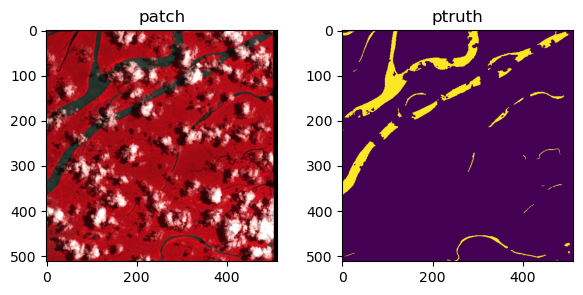

In [10]:
id = np.random.randint(0, len(valset_list))
# id = 131
patch_ptruth = valset_list[id]
patch, ptruth = patch_ptruth[0:6, :, :], patch_ptruth[6:7, :, :]
imgs_name = ['patch', 'ptruth']  
clip_list = [2, 0]  
col_bands_list = [(3,2,1), (0,0,0)]
imsShow(img_list=[patch.numpy().transpose(1,2,0), 
                  ptruth.numpy().transpose(1,2,0)], 
            img_name_list=imgs_name,    
            clip_list=clip_list,  
            color_bands_list=col_bands_list,
            figsize=(7, 3)); 
